In [104]:
import numpy as np
import pandas as pd
import os
import matplotlib.pylab as plt
import seaborn as sns
from fitter import Fitter, get_common_distributions, get_distributions
import re

<font size="5">Series de tiempo</font>

In [2]:
# 1. Leer dataframe
df = pd.read_csv("https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv")
df

,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,2023-05-12 19:00:00,1.08552,1.08569,1.08485,1.08514,2275,8,0,1.085330,-0.00038,-0.00071,-0.000545
4996,4996,2023-05-12 20:00:00,1.08516,1.08567,1.08502,1.08546,1676,8,0,1.085310,0.00032,-0.00036,-0.000020
4997,4997,2023-05-12 21:00:00,1.08546,1.08546,1.08487,1.08531,1828,8,0,1.085385,-0.00015,0.00030,0.000075
4998,4998,2023-05-12 22:00:00,1.08531,1.08549,1.08506,1.08518,1374,8,0,1.085245,-0.00013,-0.00015,-0.000140


In [3]:
# 2. Poner como indice la columna de time
df = df.rename(columns={"time":"Time", "close":"Close"})
df = df.set_index("Time")
df

,Unnamed: 0,open,high,low,Close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
Time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-05-12 19:00:00,4995,1.08552,1.08569,1.08485,1.08514,2275,8,0,1.085330,-0.00038,-0.00071,-0.000545
2023-05-12 20:00:00,4996,1.08516,1.08567,1.08502,1.08546,1676,8,0,1.085310,0.00032,-0.00036,-0.000020
2023-05-12 21:00:00,4997,1.08546,1.08546,1.08487,1.08531,1828,8,0,1.085385,-0.00015,0.00030,0.000075


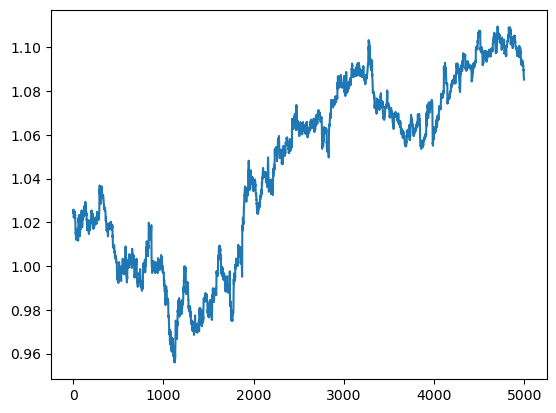

In [4]:
# 3. Obtenga informacion de DataFrame ??????????
plt.plot(df["Unnamed: 0"], df["high"])

In [5]:
# 4. Determine si hay null, nan en el data frame.
df.isnull().sum()

Unnamed: 0            0
open                  0
high                  0
low                   0
Close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64

In [8]:
# 5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.
dfw = df[['Close']]
dfw = dfw.drop(df.index[0]) ## elimino la primera fila de datos
dfw

,Close
Time,
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181
2022-07-25 18:00:00,1.02099
...,...
2023-05-12 19:00:00,1.08514
2023-05-12 20:00:00,1.08546
2023-05-12 21:00:00,1.08531


In [9]:
# 6. Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, 
#en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
dfw['DiffPrice'] = df['Close'] - df['Close'].shift(1)
dfw

,Close,DiffPrice
Time,,
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304
2022-07-25 18:00:00,1.02099,-0.00082
...,...,...
2023-05-12 19:00:00,1.08514,-0.00038
2023-05-12 20:00:00,1.08546,0.00032
2023-05-12 21:00:00,1.08531,-0.00015


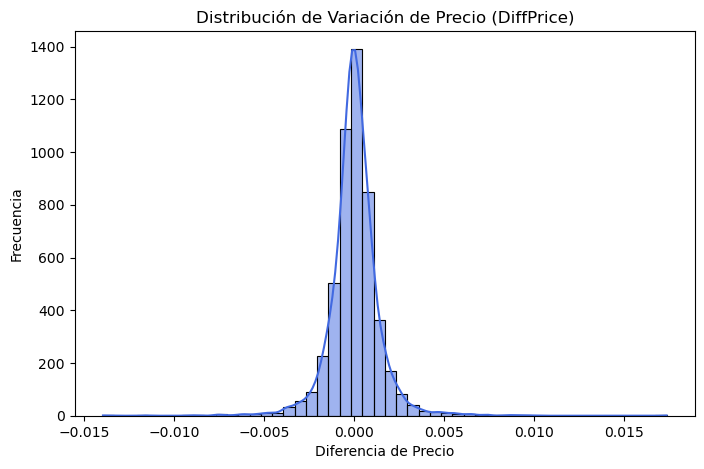

In [11]:
plt.figure(figsize=(8, 5))

# Histograma con densidad y parámetros ajustados
sns.histplot(
    data=dfw,
    x="DiffPrice",
    kde=True,  # Agrega la curva de densidad suave
    bins=50,  # Número de barras
    color="royalblue",  # Color de las barras
    edgecolor="black",  # Borde de las barras
)

plt.title("Distribución de Variación de Precio (DiffPrice)")
plt.xlabel("Diferencia de Precio")
plt.ylabel("Frecuencia")
plt.show()

In [14]:
get_distributions()

['_fit',
 'alpha',
 'anglit',
 'arcsine',
 'argus',
 'beta',
 'betaprime',
 'bradford',
 'burr',
 'burr12',
 'cauchy',
 'chi',
 'chi2',
 'cosine',
 'crystalball',
 'dgamma',
 'dpareto_lognorm',
 'dweibull',
 'erlang',
 'expon',
 'exponnorm',
 'exponpow',
 'exponweib',
 'f',
 'fatiguelife',
 'fisk',
 'foldcauchy',
 'foldnorm',
 'gamma',
 'gausshyper',
 'genexpon',
 'genextreme',
 'gengamma',
 'genhalflogistic',
 'genhyperbolic',
 'geninvgauss',
 'genlogistic',
 'gennorm',
 'genpareto',
 'gibrat',
 'gompertz',
 'gumbel_l',
 'gumbel_r',
 'halfcauchy',
 'halfgennorm',
 'halflogistic',
 'halfnorm',
 'hypsecant',
 'invgamma',
 'invgauss',
 'invweibull',
 'irwinhall',
 'jf_skew_t',
 'johnsonsb',
 'johnsonsu',
 'kappa3',
 'kappa4',
 'ksone',
 'kstwo',
 'kstwobign',
 'landau',
 'laplace',
 'laplace_asymmetric',
 'levy',
 'levy_l',
 'levy_stable',
 'loggamma',
 'logistic',
 'loglaplace',
 'lognorm',
 'loguniform',
 'lomax',
 'maxwell',
 'mielke',
 'moyal',
 'multivariate_normal',
 'nakagami',
 '

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
t,2648.868472,-53108.797686,-53089.246706,0.138297,0.012501,4.120332e-01
laplace,6365.894410,-53045.776278,-53032.742292,0.018699,0.017483,9.306124e-02
gennorm,18492.802842,-53076.176240,-53056.625261,0.029908,0.021987,1.568342e-02
cauchy,23122.545603,-52492.692248,-52479.658261,0.524401,0.042450,2.893321e-08
norm,106744.023571,-51505.717419,-51492.683433,0.102054,0.090533,4.194767e-36


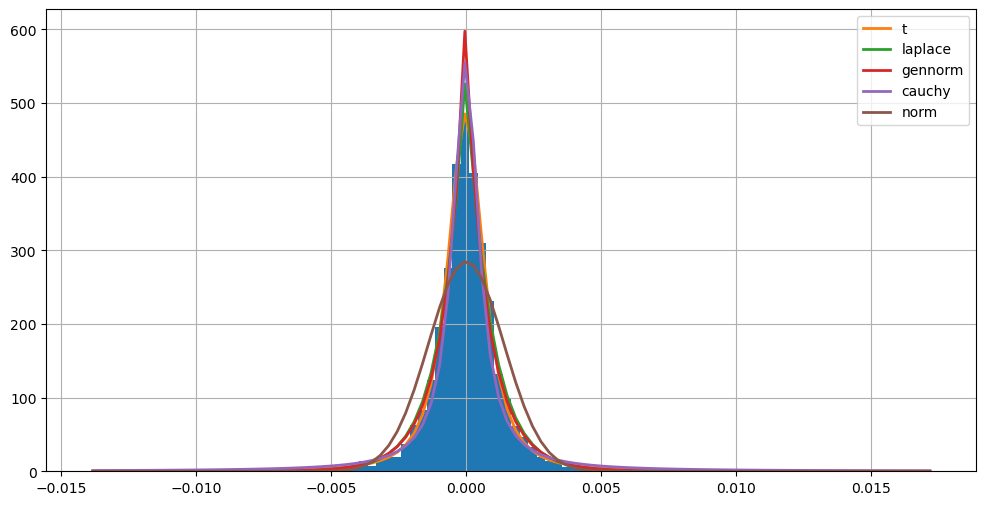

In [29]:
f = Fitter(dfw['DiffPrice'],
           distributions=["norm", 't', 'laplace', 'gennorm', 'cauchy'])
f.fit()
plt.figure(figsize=(12, 6))
f.summary()


In [18]:
f.get_best(method = 'sumsquare_error')  # la t es la distribucion que mejor se ajusta

{'t': {'df': np.float64(1.9892152720178555),
  'loc': np.float64(-3.417438470653069e-06),
  'scale': np.float64(0.0007268128428503013)}}

In [41]:
# 7. Para el data frame, seleccionemos solo los datos del 2023.
import pandas as pd

# Convertir el índice a fechas reales de Pandas
dfw.index = pd.to_datetime(dfw.index)
df_2023 = dfw.loc['2023']
df_2023

,Close,DiffPrice
Time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016
...,...,...
2023-05-12 19:00:00,1.08514,-0.00038
2023-05-12 20:00:00,1.08546,0.00032
2023-05-12 21:00:00,1.08531,-0.00015


In [62]:
# 8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. 
# Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes
print('Cada 15 días')
df_2023.groupby(pd.Grouper(freq='15D'))['DiffPrice'].mean()

Cada 15 días


Time
2023-01-02    0.000047
2023-01-17    0.000015
2023-02-01   -0.000066
2023-02-16   -0.000034
2023-03-03    0.000026
2023-03-18    0.000074
2023-04-02    0.000063
2023-04-17   -0.000006
2023-05-02   -0.000059
Freq: 15D, Name: DiffPrice, dtype: float64

In [63]:
print('Cada semana')
df_2023.groupby(pd.Grouper(freq='W'))['DiffPrice'].mean()

Cada semana


Time
2023-01-08   -0.000047
2023-01-15    0.000156
2023-01-22    0.000020
2023-01-29    0.000010
2023-02-05   -0.000062
2023-02-12   -0.000097
2023-02-19    0.000014
2023-02-26   -0.000124
2023-03-05    0.000073
2023-03-12    0.000004
2023-03-19    0.000022
2023-03-26    0.000079
2023-04-02    0.000070
2023-04-09    0.000047
2023-04-16    0.000080
2023-04-23   -0.000004
2023-04-30    0.000023
2023-05-07    0.000002
2023-05-14   -0.000140
Freq: W-SUN, Name: DiffPrice, dtype: float64

In [64]:
print('Cada mes')
df_2023.groupby(pd.Grouper(freq='ME'))['DiffPrice'].mean()

Cada mes


Time
2023-01-31    0.000031
2023-02-28   -0.000060
2023-03-31    0.000049
2023-04-30    0.000036
2023-05-31   -0.000069
Freq: ME, Name: DiffPrice, dtype: float64

In [97]:
# 9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes
q=df_2023.groupby(pd.Grouper(freq='ME'))
grupos = [(nombre.strftime("%Y-%m"), grupo) for nombre, grupo in q]

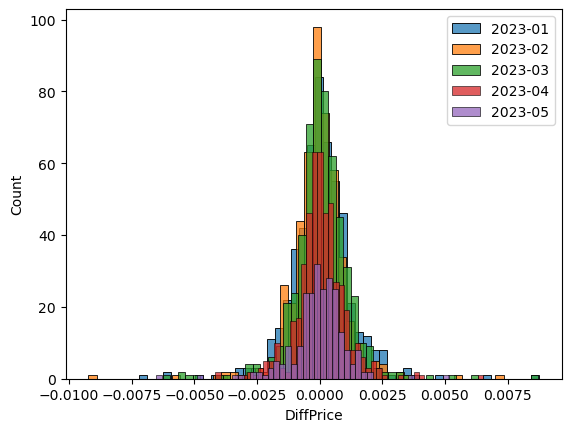

In [99]:
for (nombre, group) in q:
    sns.histplot(
    data=group['DiffPrice'],
    bins=50,  # Número de barras
#    color="royalblue",  # Color de las barras
    edgecolor="black",  # Borde de las barras
    label = nombre.strftime("%Y-%m")
    )
    plt.legend()

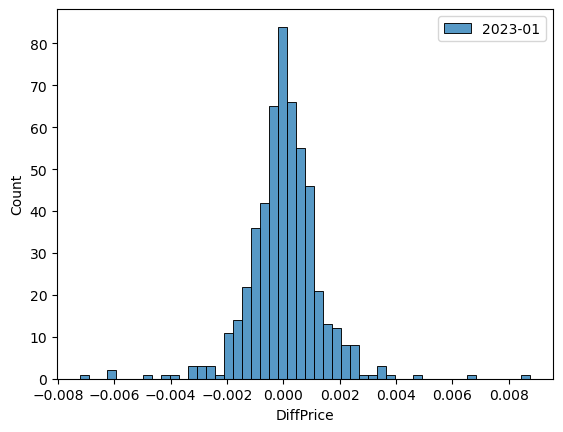

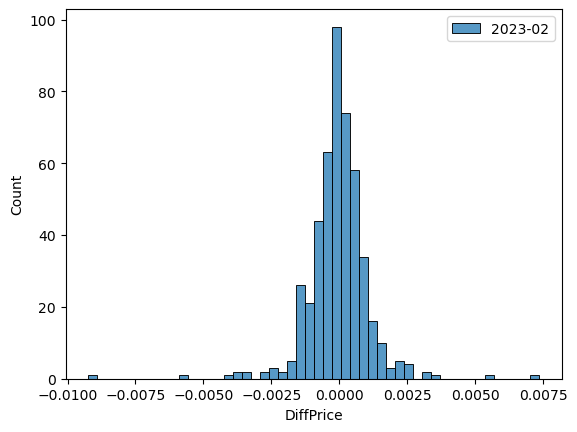

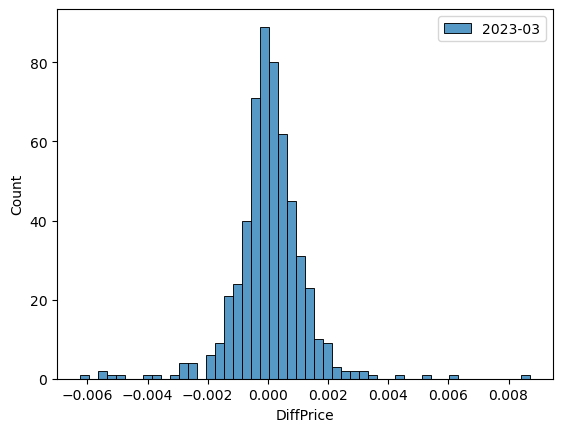

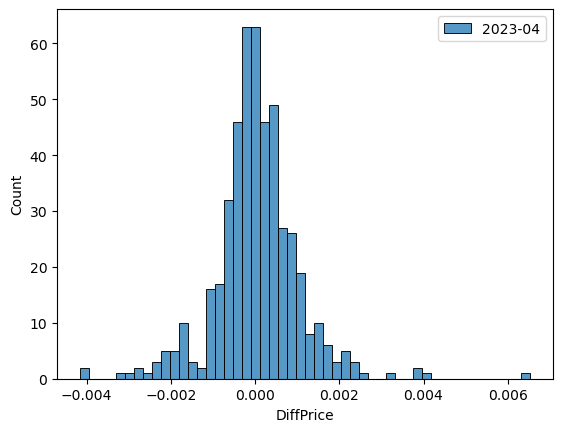

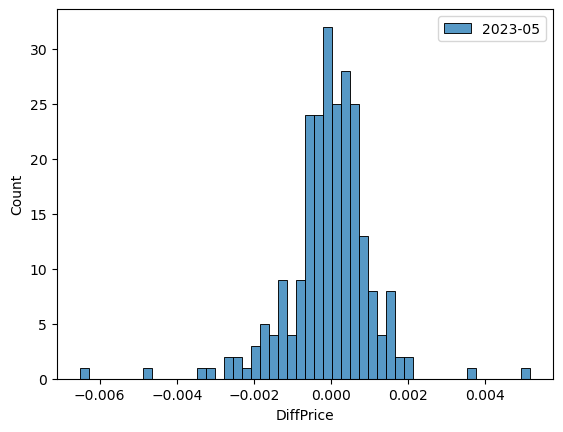

In [101]:
for (nombre, group) in q:
    plt.figure()
    sns.histplot(
    data=group['DiffPrice'],
    bins=50,  # Número de barras
#    color="royalblue",  # Color de las barras
    edgecolor="black",  # Borde de las barras
    label = nombre.strftime("%Y-%m"),
    )
    plt.legend()
    plt.show()
    

<font size="5">Análisis de datos con pandas</font>
1. Leer los datos desde una página web.


In [180]:
url = "https://archive.ics.uci.edu/static/public/17/data.csv"
ef = pd.read_csv(url)

In [181]:
ef

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


2. Renombrar las columnas en formato PascalCase

In [182]:

# 1. Definir la función de conversión a PascalCase
def to_pascal_case(texto):
    # Divide el nombre por guiones bajos, guiones medios o espacios
    palabras = re.split(r"[\s_-]+", texto)
    # Pone en mayúscula la primera letra de cada palabra
    return "".join(p[0].upper() + p[1:] for p in palabras if p)


# 2. Aplicar a las columnas del DataFrame
ef.columns = [to_pascal_case(col) for col in ef.columns]
ef

,ID,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


3. Utilizar los métodos head(), tail(), describe() e info() para obtener información sobre el DataFrame.

In [183]:
ef.head()

,ID,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [184]:
ef.tail()

,ID,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M
568,92751,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,B


In [185]:
ef.describe()

,ID,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [186]:
ef.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 569 non-null    int64  
 1   Radius1            569 non-null    float64
 2   Texture1           569 non-null    float64
 3   Perimeter1         569 non-null    float64
 4   Area1              569 non-null    float64
 5   Smoothness1        569 non-null    float64
 6   Compactness1       569 non-null    float64
 7   Concavity1         569 non-null    float64
 8   ConcavePoints1     569 non-null    float64
 9   Symmetry1          569 non-null    float64
 10  FractalDimension1  569 non-null    float64
 11  Radius2            569 non-null    float64
 12  Texture2           569 non-null    float64
 13  Perimeter2         569 non-null    float64
 14  Area2              569 non-null    float64
 15  Smoothness2        569 non-null    float64
 16  Compactness2       569 non

4. Contabilizar la cantidad de valores nulos (null o NaN) en el DataFrame. Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

In [187]:
ef.isnull().sum()

ID                   0
Radius1              0
Texture1             0
Perimeter1           0
Area1                0
Smoothness1          0
Compactness1         0
Concavity1           0
ConcavePoints1       0
Symmetry1            0
FractalDimension1    0
Radius2              0
Texture2             0
Perimeter2           0
Area2                0
Smoothness2          0
Compactness2         0
Concavity2           0
ConcavePoints2       0
Symmetry2            0
FractalDimension2    0
Radius3              0
Texture3             0
Perimeter3           0
Area3                0
Smoothness3          0
Compactness3         0
Concavity3           0
ConcavePoints3       0
Symmetry3            0
FractalDimension3    0
Diagnosis            0
dtype: int64

5. Identificar los valores únicos en la columna target que representan las etiquetas B y M (Benigno y Maligno, respectivamente). Utiliza el método unique() para mostrar estos valores.

In [188]:
print(ef["Diagnosis"].unique())

['M' 'B']


6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería seaborn y el método countplot().

<Axes: xlabel='Diagnosis', ylabel='count'>

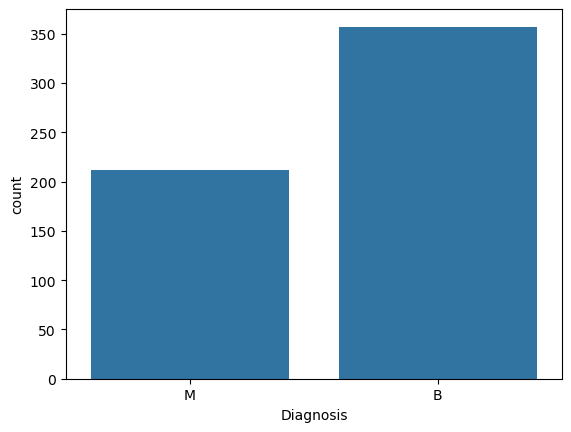

In [189]:
sns.countplot(ef, x = 'Diagnosis')

7. Agregar una nueva columna llamada DiagnosisNumeric donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).

In [190]:
ef['DiagnosisNumeric'] = ef["Diagnosis"].map({"M": 1, "B": 0}).astype(int) 
# map convierte a nan aquellas categorias no declaradas
ef

,ID,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis,DiagnosisNumeric
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M,1
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M,1
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M,1
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M,1


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:
(x - mean(x)) / std(x.)

In [191]:
columnas_numericas = ef.select_dtypes(include=['float64']).columns
ef_norm = ef.copy()
for columna in columnas_numericas:
    ef_norm[columna] = ef[columna] - ef[columna].mean()/ef[columna].std()

ef_norm

,ID,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis,DiagnosisNumeric
0,842302,13.981176,5.895116,119.015107,999.139066,-6.733093,-1.698078,-0.813793,-1.11361,-6.366402,...,181.407944,2017.453373,-5.635194,-0.950459,-0.592783,-1.478129,-4.228561,-4.528936,M,1
1,842517,16.561176,13.285116,129.115107,1324.139066,-6.766753,-1.897038,-1.026993,-1.19054,-6.427102,...,155.607944,1954.453373,-5.673594,-1.429459,-1.063083,-1.557529,-4.413661,-4.558816,M,1
2,84300903,15.681176,16.765116,126.215107,1201.139066,-6.741893,-1.815778,-0.916493,-1.13281,-6.401402,...,149.307944,1707.453373,-5.652994,-1.191559,-0.854283,-1.500529,-4.327361,-4.560256,M,1
3,84348301,7.411176,15.895116,73.795107,384.239066,-6.708993,-1.691778,-0.872493,-1.15551,-6.348602,...,95.677944,566.153373,-5.587594,-0.749759,-0.617783,-1.486029,-4.024861,-4.474836,M,1
4,84358402,16.281176,9.855116,131.315107,1295.139066,-6.751193,-1.842878,-0.915893,-1.15641,-6.427402,...,149.007944,1573.453373,-5.659994,-1.411059,-0.904683,-1.581029,-4.452261,-4.571056,M,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,17.551176,17.905116,138.215107,1477.139066,-6.740493,-1.859778,-0.869993,-1.12181,-6.435702,...,162.907944,2025.453373,-5.656394,-1.404759,-0.893983,-1.521929,-4.482661,-4.576686,M,1
565,926682,16.121176,23.765116,127.415107,1259.139066,-6.753693,-1.872278,-0.969893,-1.16280,-6.433102,...,151.807944,1729.453373,-5.680794,-1.423859,-0.983183,-1.580729,-4.431461,-4.581466,M,1
566,926954,12.591176,23.595116,104.515107,856.239066,-6.766943,-1.873378,-1.021383,-1.20769,-6.449302,...,123.507944,1122.453373,-5.683494,-1.306659,-0.964383,-1.601729,-4.466861,-4.569636,M,1
567,927241,16.591176,24.845116,136.315107,1263.139066,-6.733693,-1.698678,-0.762493,-1.10871,-6.368602,...,181.407944,1819.453373,-5.632394,-0.747959,-0.365983,-1.478529,-4.279961,-4.523836,M,1


9. Agrupar características similares y calcular su promedio. Para las siguientes características:

['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
Usa expresiones regulares para identificar patrones comunes, como radius1, radius2,radius3, etc., y calcular los promedios. Por ejemplo:

re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
También puedes utilizar el método startswith() para buscar estos patrones en los nombres de las columnas.

In [192]:
caracteristicas_mean = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"] 

caracteristicas = [palabra[0:len(palabra)-4] for palabra in caracteristicas_mean]
caracteristicas

['Radius',
 'Texture',
 'Perimeter',
 'Area',
 'Smoothness',
 'Compactness',
 'Concavity',
 'ConcavePoints',
 'Symmetry',
 'FractalDimension']

In [197]:
for caracteristica in caracteristicas:
    suma = np.zeros(569)
    for col_num in columnas_numericas:
        if col_num.startswith(caracteristica):
            suma += ef[col_num]
    til = caracteristica+'Mean'
    ef[til] = suma/3            

10. Crear un gráfico donde se muestre el histograma de la columna RadiusMean separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

In [198]:
tm = ef[ef['DiagnosisNumeric'] == 1]
tb = ef[ef['DiagnosisNumeric'] == 0]

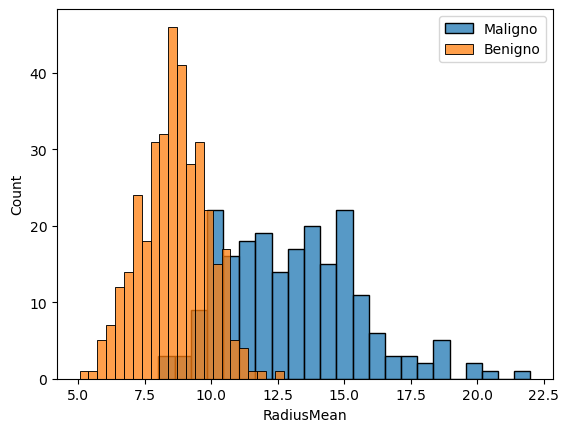

In [200]:
sns.histplot(
    data=tm,
    x = 'RadiusMean',
    bins=int(np.sqrt(569)),  # Número de barras
#    color="royalblue",  # Color de las barras
    edgecolor="black",  # Borde de las barras
    label = nombre.strftime("Maligno")
    )

sns.histplot(
    data=tb,
    x = 'RadiusMean',
    bins=int(np.sqrt(569)),  # Número de barras
#    color="royalblue",  # Color de las barras
    edgecolor="black",  # Borde de las barras
    label = nombre.strftime("Benigno")
    )
plt.legend()

11. Generar gráficos de violín para múltiples características. Para las columnas:

RadiusMean
TextureMean
PerimeterMean
AreaMean
SmoothnessMean
CompactnessMean
ConcavityMean
ConcavePointsMean
Symmetry3
FractalDimension3
Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)

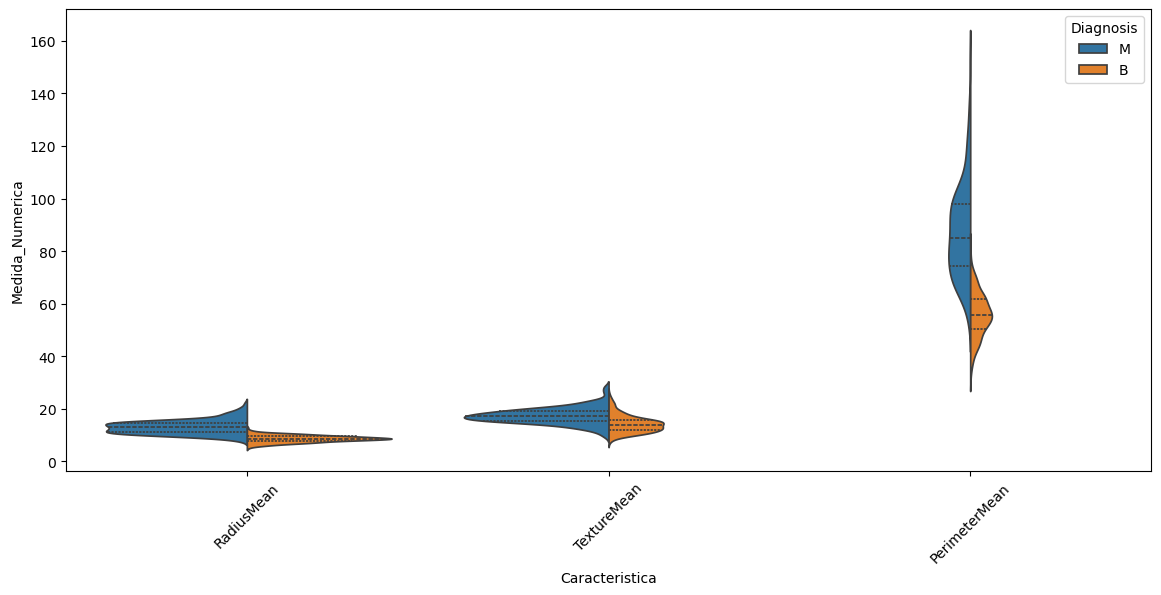

In [217]:
# 1. Separamos las primeras columnas de características
datos_recortados = ef.iloc[:, -10:-7].copy()

# 2. Le pegamos a la fuerza la columna de diagnóstico original
datos_recortados['Diagnosis'] = ef['Diagnosis']

# 3. Ahora ejecutamos el melt sobre esta tabla segura
tabla_larga = pd.melt(
    datos_recortados,             
    id_vars="Diagnosis",          
    var_name="Caracteristica",    
    value_name="Medida_Numerica"  
)

# 4. Generamos el gráfico
plt.figure(figsize=(14, 6))       
sns.violinplot(
    data=tabla_larga, 
    x="Caracteristica",           
    y="Medida_Numerica",          
    hue="Diagnosis",              
    split=True,                   
    inner="quart"                 
)

plt.xticks(rotation=45)           
plt.show()

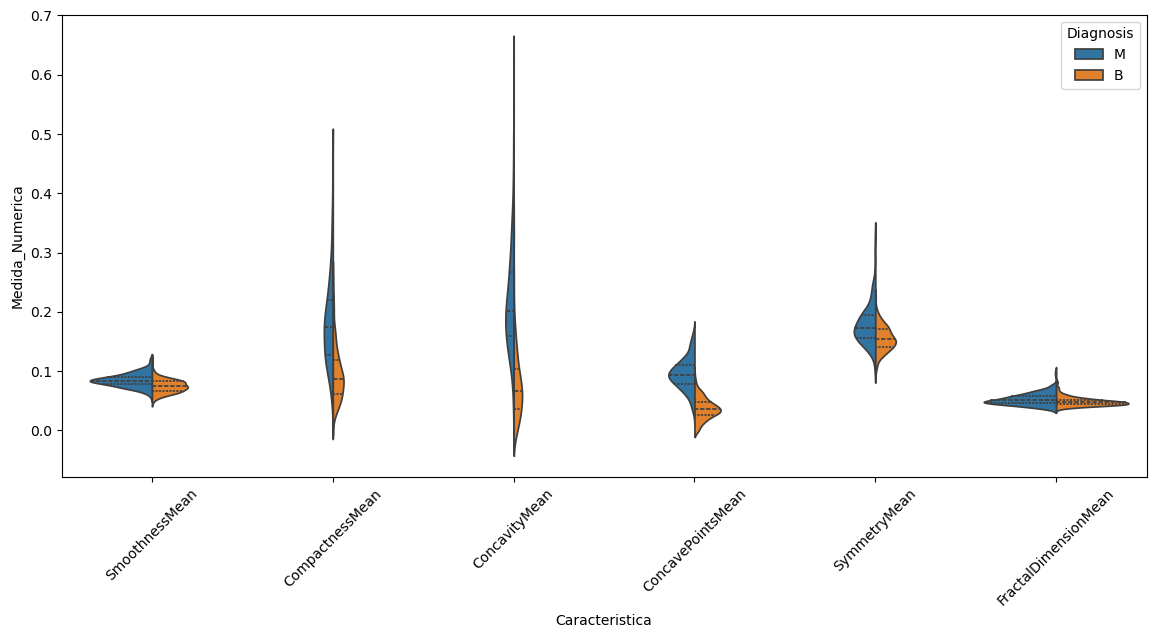

In [229]:
# 1. Separamos las primeras 10 columnas de características
datos_recortados = ef.iloc[:, -6:].copy()

# 2. Le pegamos a la fuerza la columna de diagnóstico original
datos_recortados['Diagnosis'] = ef['Diagnosis']

# 3. Ahora ejecutamos el melt sobre esta tabla segura
tabla_larga = pd.melt(
    datos_recortados,             
    id_vars="Diagnosis",          
    var_name="Caracteristica",    
    value_name="Medida_Numerica"  
)

# 4. Generamos el gráfico
plt.figure(figsize=(14, 6))       
sns.violinplot(
    data=tabla_larga, 
    x="Caracteristica",           
    y="Medida_Numerica",          
    hue="Diagnosis",              
    split=True,                   
    inner="quart"                 
)

plt.xticks(rotation=45)           
plt.show()

<Figure size 800x600 with 0 Axes>

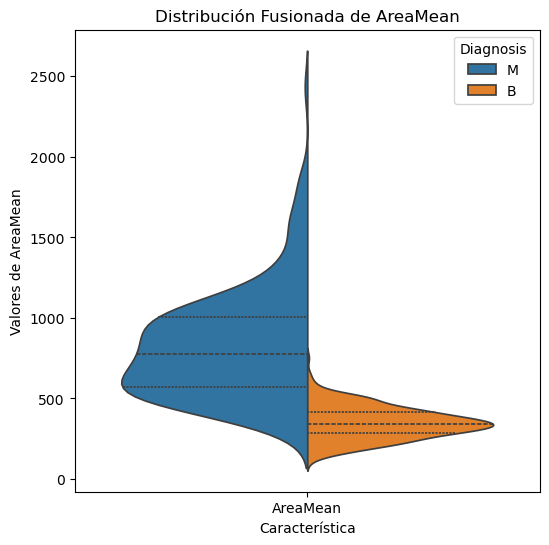

In [240]:
plt.figure(figsize=(8, 6))

# 1. 'Melt' exclusivo para AreaMean
df_area = pd.melt(ef, id_vars=['Diagnosis'], value_vars=['AreaMean'])

# 2. Violín único fusionado
plt.figure(figsize=(6, 6))
sns.violinplot(
    data=df_area,
    x="variable",       # Forzamos una sola categoría en el eje X ("AreaMean")
    y="value",          # Eje Y con la escala de valores
    hue="Diagnosis",    # Separa por color según el diagnóstico
    split=True,         # Pega la mitad izquierda y la derecha en una sola figura
    inner="quart"       # Líneas punteadas de cuartiles
)

plt.xlabel("Característica")
plt.ylabel("Valores de AreaMean")
plt.title("Distribución Fusionada de AreaMean")
plt.show()

12. Determinar y eliminar los valores atípicos (outliers) en la columna RadiusMean.
Para identificarlos, construye un gráfico tipo boxplot:

df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
Otra alternativa es utilizar el puntaje Z para detectar outliers:

df = df[(np.abs(stats.zscore(df['edad'])) < 3)]

<Axes: title={'center': 'RadiusMean'}, xlabel='Diagnosis'>

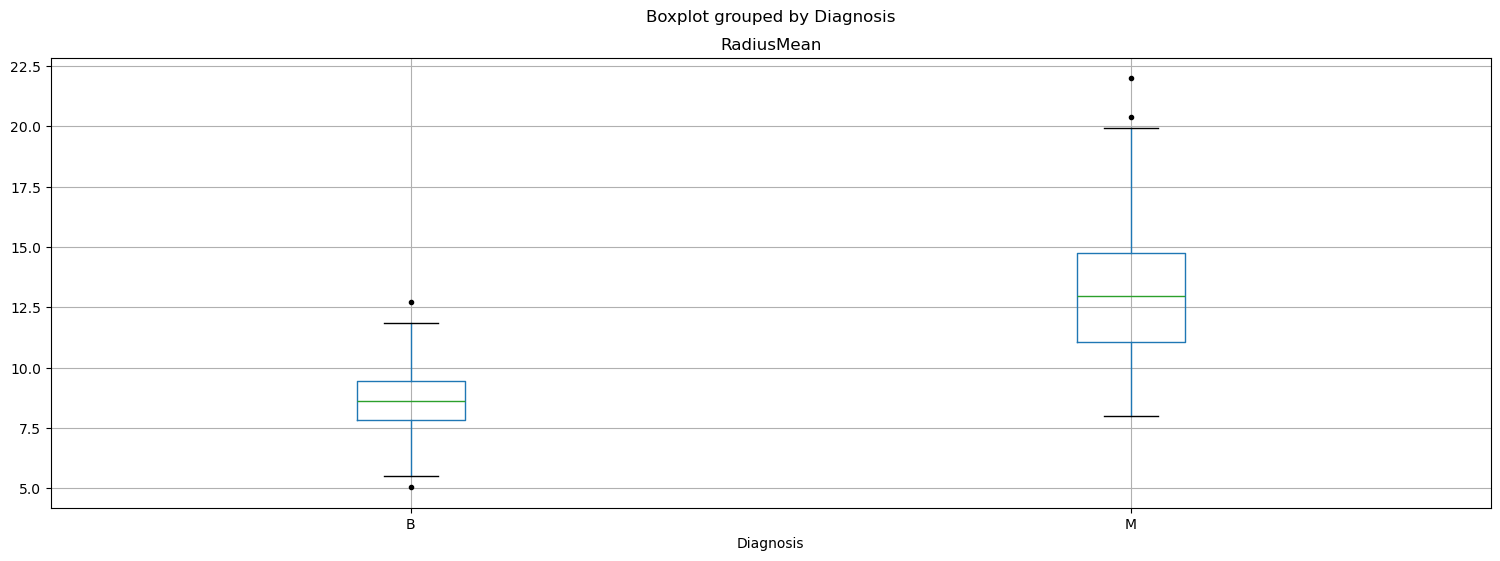

In [220]:
ef.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6)) 

<Axes: title={'center': 'RadiusMean'}, xlabel='Diagnosis'>

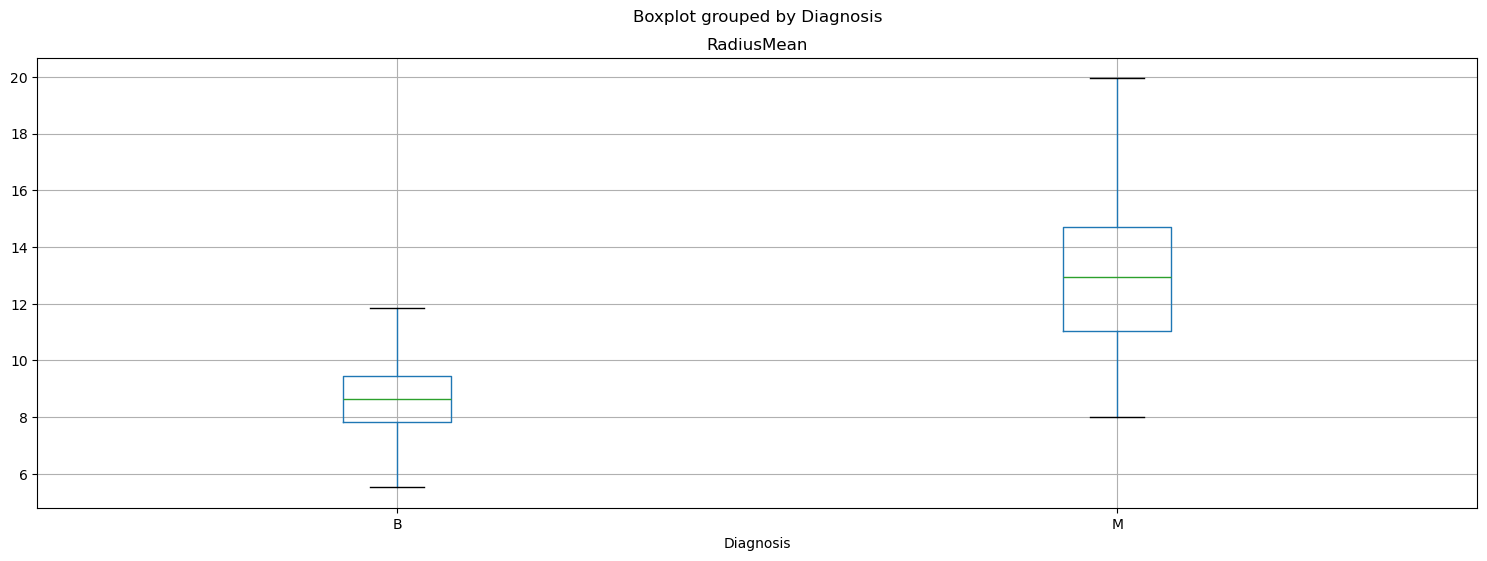

In [242]:
# Cuartiles benignos
Q1_b = tb['RadiusMean'].quantile(0.25)
Q3_b = tb['RadiusMean'].quantile(0.75)
IQR_b = Q3_b - Q1_b

# Cuartiles malignos
Q1_m = tm['RadiusMean'].quantile(0.25)
Q3_m = tm['RadiusMean'].quantile(0.75)
IQR_m = Q3_m - Q1_m

# Filtrar outliers
tb_limpio = tb[(tb['RadiusMean'] >= (Q1_b - 1.5 * IQR_b)) & (tb['RadiusMean'] <= (Q3_b + 1.5 * IQR_b))]
tm_limpio = tm[(tm['RadiusMean'] >= (Q1_m - 1.5 * IQR_m)) & (tm['RadiusMean'] <= (Q3_m + 1.5 * IQR_m))]

# Concatenar
t_red = pd.concat([tb_limpio, tm_limpio])

t_red.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18, 6))

13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

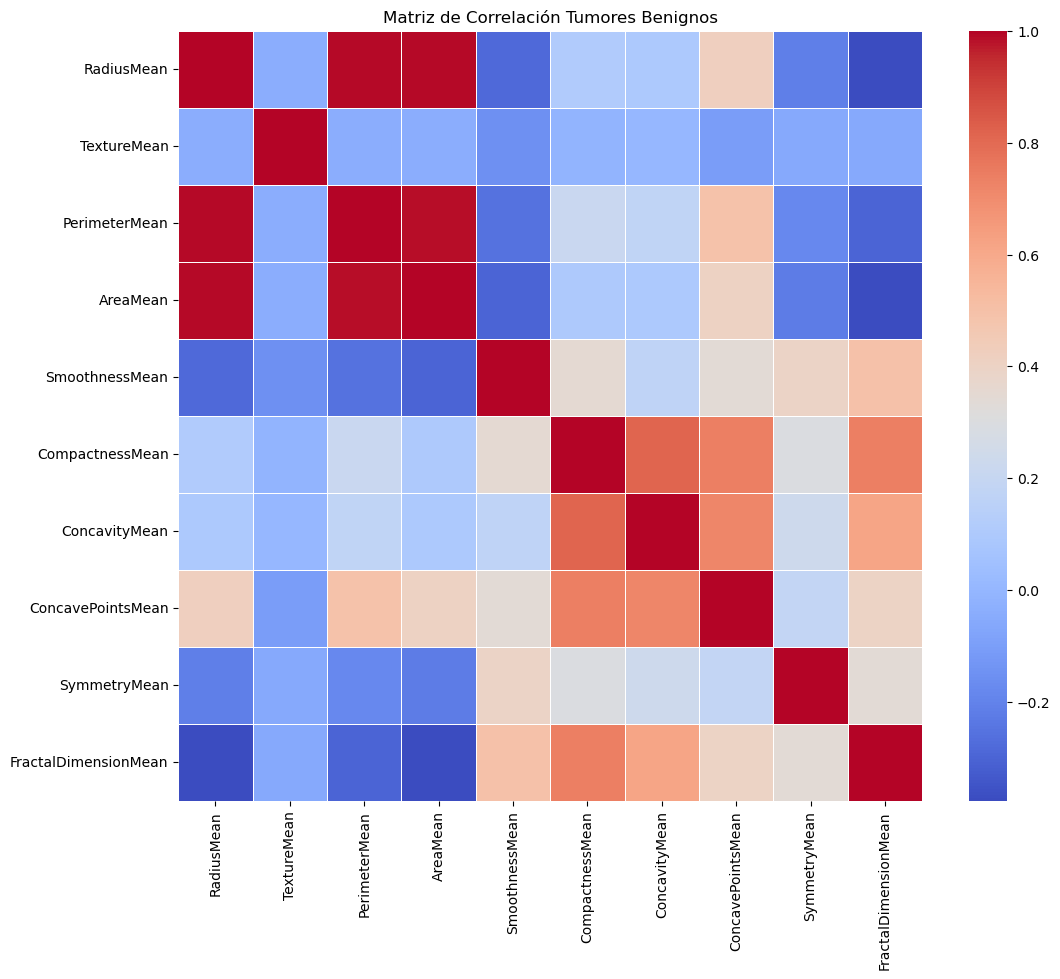

In [233]:
# 1. Calcula la matriz usando solo los números
tbdos = tb.iloc[:, -10:].copy()
matriz_corr = tbdos.corr(numeric_only=True)

# 2. Agranda el lienzo para que los cuadritos no se aplasten
plt.figure(figsize=(12, 10))

# 3. Genera el mapa de calor
sns.heatmap(
    matriz_corr, 
    cmap="coolwarm",      # Usa rojo para correlación alta y azul para inversa
    annot=False,          # Cambialo a True si querés ver el número exacto adentro de cada cuadro
    fmt=".2f",            # Si activás annot, esto redondea los números a dos decimales
    linewidths=0.5        # Dibuja una separación finita entre los cuadros
)

plt.title("Matriz de Correlación Tumores Benignos")
plt.show()

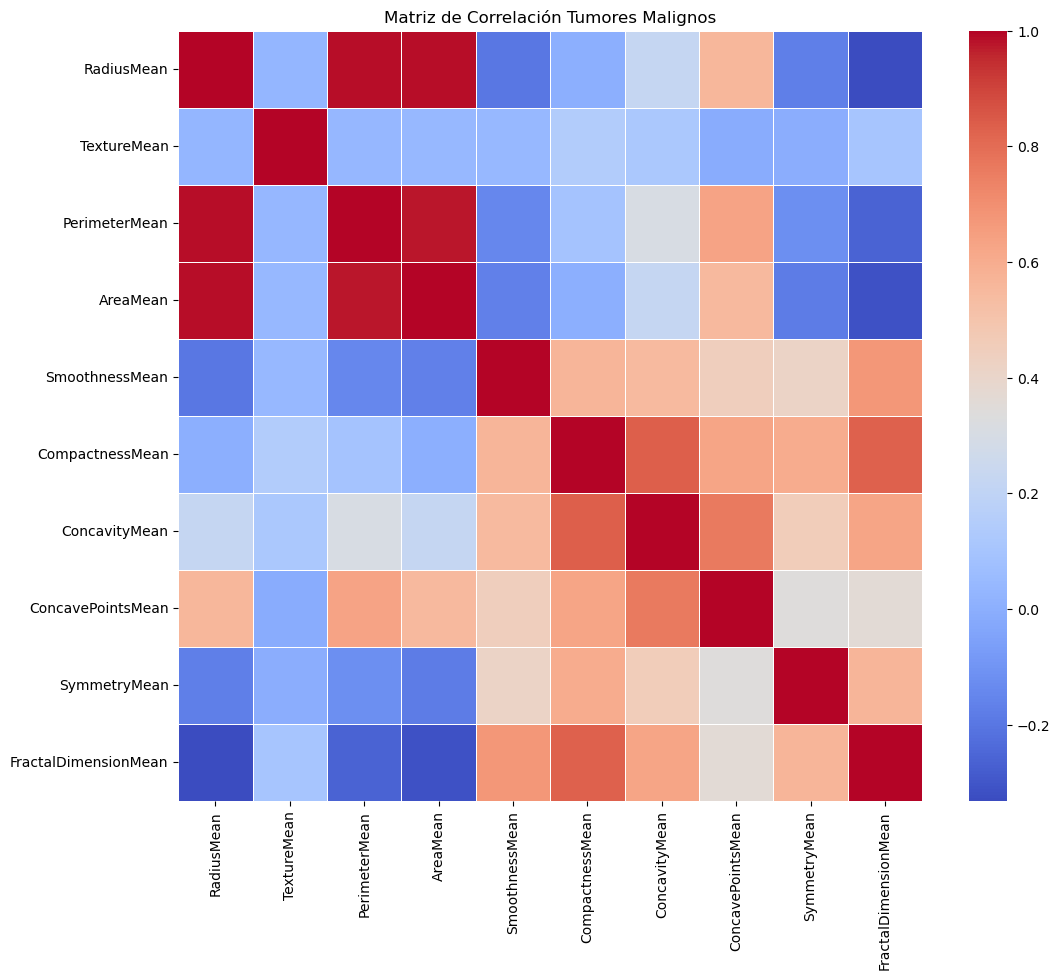

In [241]:
# 1. Calcula la matriz usando solo los números
tmdos = tm.iloc[:, -10:].copy()
matriz_corr = tmdos.corr(numeric_only=True)

# 2. Agranda el lienzo para que los cuadritos no se aplasten
plt.figure(figsize=(12, 10))

# 3. Genera el mapa de calor
sns.heatmap(
    matriz_corr, 
    cmap="coolwarm",      # Usa rojo para correlación alta y azul para inversa
    annot=False,          # Cambialo a True si querés ver el número exacto adentro de cada cuadro
    fmt=".2f",            # Si activás annot, esto redondea los números a dos decimales
    linewidths=0.5        # Dibuja una separación finita entre los cuadros
)

plt.title("Matriz de Correlación Tumores Malignos")
plt.show()

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos? Proyección PCA puede ser útil porque las variables geométrica de area, radio y perímetro están fuertemente relacionadas, pues al fin y al cabo dan igual cuenta del tamaño de las celulas del tumor. La región del cuadrante derecho inferior (cuyos parámetros están relacionados con la deformidad del tumor) muestra una serie de correlaciones positivas más fuertes en los tumores malignos que en los benignos. Para compara esto efectivamente, tal se podrían comparar las rectas de cada y vs x por diagnóstico.